In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q ultralytics transformers tensorflow opencv-python-headless tqdm

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install -q transformers --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.3/596.3 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 112.9 MB/s eta 0:00:00


In [ ]:
!pip uninstall -y transformers
!pip install transformers==4.37.2

Found existing installation: transformers 5.3.0
Uninstalling transformers-5.3.0:
  Successfully uninstalled transformers-5.3.0
  Using cached transformers-4.37.2-py3-none-any.whl.metadata (129 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.15.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
Using cached transformers-4.37.2-py3-none-any.whl (8.4 MB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
Using cached tokenizers-0.15.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.6 MB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.5.0
    Uninstalling huggingface_hub-1.5.0:
      Successfully uninstalled huggingface_hub-1.5.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
ERROR: pip's dependency resolver does not 

In [ ]:
# Basic libraries
import os
import cv2
import numpy as np
import pickle
import random
from tqdm import tqdm

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Dense,
    LSTM,
    Embedding,
    Dropout,
    Bidirectional,
    Add
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping

# Visualization
import matplotlib.pyplot as plt

# YOLO
from ultralytics import YOLO

# Vision Transformer
from transformers import ViTImageProcessor, TFViTModel

In [ ]:
# YOLO model
yolo = YOLO("yolov8n.pt")

# Vision Transformer (PyTorch version for feature extraction)
from transformers import ViTImageProcessor, ViTModel
import torch

vit_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224")

# use GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
vit_model.to(device)

print("ViT loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViT loaded successfully


In [ ]:
BASE_DIR = "/content/drive/MyDrive/Flickr8k"

IMAGE_DIR = os.path.join(BASE_DIR, "Images")
CAPTION_FILE = os.path.join(BASE_DIR, "captions.txt")

FEATURE_FILE = "/content/drive/MyDrive/vit_yolo_features.pkl"
TOKENIZER_FILE = "/content/drive/MyDrive/tokenizer.pkl"
MODEL_FILE = "/content/drive/MyDrive/caption_model.keras"

In [ ]:
def load_captions(filename):

    mapping = {}

    with open(filename, "r") as f:

        for line in f:

            tokens = line.strip().split(",")

            image_id = tokens[0].split(".")[0]
            caption = tokens[1]

            caption = "startseq " + caption + " endseq"

            if image_id not in mapping:
                mapping[image_id] = []

            mapping[image_id].append(caption)

    return mapping


captions = load_captions(CAPTION_FILE)

print("Total images:", len(captions))

Total images: 8092


In [ ]:
# YOLO
yolo = YOLO("yolov8n.pt")

# ViT
from transformers import ViTImageProcessor, ViTModel
import torch

vit_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224")

device = "cuda" if torch.cuda.is_available() else "cpu"
vit_model.to(device)

print("Models loaded successfully")

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Models loaded successfully


In [ ]:
features = {}

# load previously saved features
if os.path.exists(FEATURE_FILE):

    with open(FEATURE_FILE, "rb") as f:
        features = pickle.load(f)

    print("Loaded existing features:", len(features))


image_list = os.listdir(IMAGE_DIR)

batch_size = 32
batch_images = []
batch_ids = []

for img_name in tqdm(image_list):

    image_id = img_name.split(".")[0]

    if image_id in features:
        continue

    img_path = os.path.join(IMAGE_DIR, img_name)

    img = cv2.imread(img_path)

    if img is None:
        continue

    # -------- YOLO detection --------
    results = yolo(img, verbose=False)

    objects = []

    for cls in results[0].boxes.cls:
        label = results[0].names[int(cls)]
        objects.append(label)

    object_text = " ".join(list(set(objects)))

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    batch_images.append(img_rgb)
    batch_ids.append((image_id, object_text))


    # ---------- run batch through ViT ----------
    if len(batch_images) == batch_size:

        inputs = vit_processor(images=batch_images, return_tensors="pt").to(device)

        with torch.no_grad():

            outputs = vit_model(**inputs)

        batch_features = outputs.last_hidden_state[:,0,:].cpu().numpy()

        for i,(img_id,obj_text) in enumerate(batch_ids):

            features[img_id] = [batch_features[i], obj_text]

        batch_images = []
        batch_ids = []


        # save periodically
        if len(features) % 1000 == 0:

            with open(FEATURE_FILE, "wb") as f:
                pickle.dump(features, f)

            print("Saved:", len(features))


# process remaining images
if len(batch_images) > 0:

    inputs = vit_processor(images=batch_images, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = vit_model(**inputs)

    batch_features = outputs.last_hidden_state[:,0,:].cpu().numpy()

    for i,(img_id,obj_text) in enumerate(batch_ids):

        features[img_id] = [batch_features[i], obj_text]


# final save
with open(FEATURE_FILE, "wb") as f:
    pickle.dump(features, f)

print("Feature extraction complete:", len(features))

Loaded existing features: 8090


100%|██████████| 8090/8090 [00:00<00:00, 411980.13it/s]


Feature extraction complete: 8090


In [ ]:
import pickle

with open(FEATURE_FILE, "rb") as f:
    features = pickle.load(f)

print("Total features loaded:", len(features))

Total features loaded: 8090


In [ ]:
all_captions = []

for key, caps in captions.items():

    if key not in features:
        continue

    object_text = features[key][1]

    for cap in caps:

        cap = "startseq " + object_text + " " + cap.replace("startseq","").strip()

        all_captions.append(cap)

print("Total captions:", len(all_captions))

Total captions: 40450


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
import pickle

all_captions = []

for key, caps in captions.items():

    if key not in features:
        continue

    object_text = features[key][1]

    for cap in caps:
        cap = "startseq " + object_text + " " + cap.replace("startseq","").strip()
        all_captions.append(cap)

tokenizer = Tokenizer(num_words=8000, oov_token="<unk>")
tokenizer.fit_on_texts(all_captions)

vocab_size = 8000
max_length = max(len(c.split()) for c in all_captions)

print("Vocabulary size:", vocab_size)
print("Max length:", max_length)

with open(TOKENIZER_FILE, "wb") as f:
    pickle.dump(tokenizer, f)

Vocabulary size: 8000
Max length: 39


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

X1, X2, y = [], [], []

for key, caps in captions.items():

    if key not in features:
        continue

    photo = features[key][0]
    object_text = features[key][1]

    for caption in caps:

        caption = "startseq " + object_text + " " + caption.replace("startseq","").strip()

        seq = tokenizer.texts_to_sequences([caption])[0]

        for i in range(1, len(seq)):

            in_seq = seq[:i]
            out_seq = seq[i]

            in_seq = pad_sequences([in_seq], maxlen=max_length)[0]

            X1.append(photo)
            X2.append(in_seq)
            y.append(out_seq)

# convert to numpy
X1 = np.array(X1, dtype="float32")
X2 = np.array(X2, dtype="int32")
y  = np.array(y, dtype="int32")

print(X1.shape, X2.shape, y.shape)

(537763, 768) (537763, 39) (537763,)


In [ ]:
limit = 150000

X1 = X1[:limit]
X2 = X2[:limit]
y  = y[:limit]

print("Training size:", X1.shape)

Training size: (150000, 768)


In [ ]:
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Bidirectional, Add
from tensorflow.keras.models import Model

# Image branch
inputs1 = Input(shape=(768,))
fe1 = Dense(256, activation="relu")(inputs1)
fe2 = Dropout(0.5)(fe1)

# Text branch
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256)(inputs2)

se2 = Bidirectional(LSTM(256))(se1)

# reduce 512 → 256
se3 = Dense(256)(se2)

# Decoder
decoder = Add()([fe2, se3])
decoder = Dense(256, activation="relu")(decoder)

outputs = Dense(vocab_size, activation="softmax")(decoder)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam"
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 39)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 768)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 39, 256)   │  2,048,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    196,864 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 512)       │  1,050,624 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dropout[0][0],    │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 8000)      │  2,056,000 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,548,608 (21.17 MB)

 Trainable params: 5,548,608 (21.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="loss",
    patience=3,
    restore_best_weights=True
)

model.fit(
    [X1, X2],
    y,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/30
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 4.4995
Epoch 2/30
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 34s 15ms/step - loss: 3.2353
Epoch 3/30
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 2.9229
Epoch 4/30
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 2.7255
Epoch 5/30
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - loss: 2.5628
Epoch 6/30
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 2.4475
Epoch 7/30
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 2.3454
Epoch 8/30
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 2.2714
Epoch 9/30
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 2.1930
Epoch 10/30
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 2.1123
Epoch 11/30
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 2.0573
Epoch 12/30
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - loss: 2.0040
Epoch 13/30
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 1.9527
Epoch 14/30
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - loss: 1.9030
E

In [ ]:
MODEL_FILE = "/content/drive/MyDrive/caption_model.keras"

model.save(MODEL_FILE)

print("Model saved successfully.")

Model saved successfully.


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

def generate_caption(model, tokenizer, photo, max_length, beam_index=3):

    start = [tokenizer.word_index["startseq"]]
    sequences = [[start, 0]]

    while len(sequences[0][0]) < max_length:

        all_candidates = []

        for seq, score in sequences:

            padded = pad_sequences([seq], maxlen=max_length)

            preds = model.predict([photo.reshape(1,-1), padded], verbose=0)[0]

            top_words = np.argsort(preds)[-beam_index:]

            for word in top_words:
                candidate = [seq + [word], score + np.log(preds[word])]
                all_candidates.append(candidate)

        ordered = sorted(all_candidates, key=lambda tup: tup[1], reverse=True)
        sequences = ordered[:beam_index]

    final_seq = sequences[0][0]

    caption = []

    for idx in final_seq:

        word = tokenizer.index_word.get(idx)

        if word == "endseq":
            break

        if word != "startseq":
            caption.append(word)

    return " ".join(caption)

Generated Caption: dog a black and white dog is running through the sand at a beach


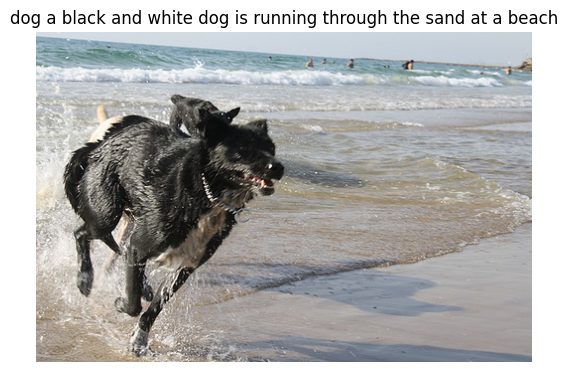

In [ ]:
import random
import matplotlib.pyplot as plt

image_id = random.choice(list(features.keys()))

photo = features[image_id][0]

caption = generate_caption(model, tokenizer, photo, max_length)

print("Generated Caption:", caption)

img = cv2.imread(os.path.join(IMAGE_DIR, image_id + ".jpg"))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.title(caption)
plt.show()

In [ ]:
with open("/content/drive/MyDrive/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved.")

Tokenizer saved.
